# YOLO11-seg + SAM2: Instance & Promptable Segmentation

Cleaned-up version — bug fixes and small robustness/readability improvements are noted inline as comments.

In [ ]:
import os
import urllib.request

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


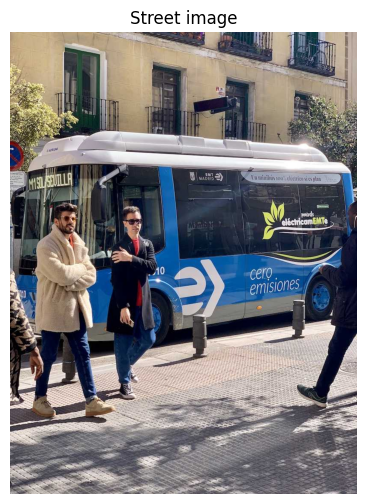

In [ ]:
def load_image_from_url(url: str) -> np.ndarray:
    """Download an image from a URL and return it as an RGB numpy array."""
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request) as response:
        image_bytes = bytearray(response.read())
    image_array = np.asarray(image_bytes, dtype=np.uint8)
    image_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not decode image from {url}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def show_image(image: np.ndarray, title: str = "", figsize=(8, 6)):
    """Display an image with no axes and an optional title."""
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()


street_img = load_image_from_url(
    "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
)
dogs_img = load_image_from_url(
    "https://images.unsplash.com/photo-1548199973-03cce0bbc87b?w=800&q=80"
)

show_image(street_img, "Street image")

In [ ]:
%pip install -q ultralytics
%pip install -q "git+https://github.com/facebookresearch/sam2.git"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.1 MB/s eta 0:00:00


## YOLO11 instance segmentation

In [ ]:
from ultralytics import YOLO

yolo_model = YOLO("yolo11n-seg.pt")
yolo_model.to(device)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_runni


0: 448x640 2 dogs, 532.6ms
Speed: 25.3ms preprocess, 532.6ms inference, 46.8ms postprocess per image at shape (1, 3, 448, 640)


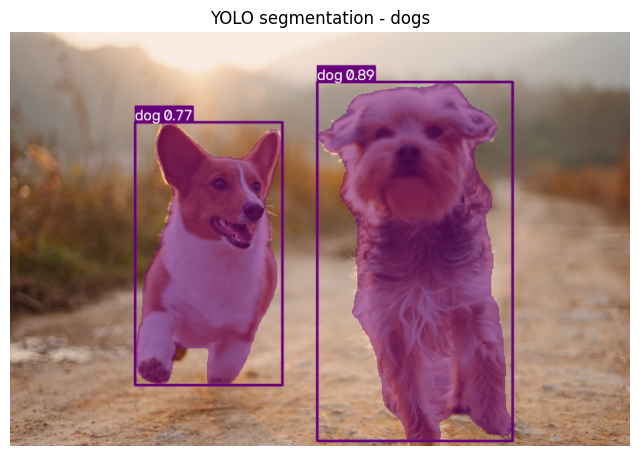

In [ ]:
dogs_results = yolo_model(dogs_img, conf=0.35)
show_image(dogs_results[0].plot(), "YOLO segmentation - dogs")


0: 640x480 4 persons, 1 bus, 255.1ms
Speed: 8.7ms preprocess, 255.1ms inference, 10.2ms postprocess per image at shape (1, 3, 640, 480)


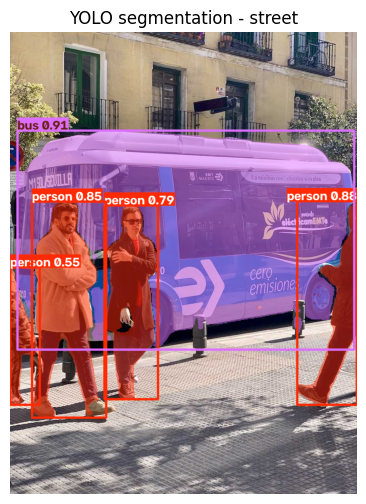

In [ ]:
street_results = yolo_model(street_img, conf=0.35)
show_image(street_results[0].plot(), "YOLO segmentation - street")

In [ ]:
print(street_results[0].boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.])
conf: tensor([0.9051, 0.8784, 0.8456, 0.7910, 0.5458])
data: tensor([[1.7845e+01, 2.3016e+02, 8.0348e+02, 7.4255e+02, 9.0514e-01, 5.0000e+00],
        [6.7021e+02, 3.9520e+02, 8.0953e+02, 8.7177e+02, 8.7837e-01, 0.0000e+00],
        [5.1574e+01, 3.9681e+02, 2.2405e+02, 9.0152e+02, 8.4561e-01, 0.0000e+00],
        [2.2072e+02, 4.0508e+02, 3.4576e+02, 8.5821e+02, 7.9099e-01, 0.0000e+00],
        [0.0000e+00, 5.5005e+02, 6.9072e+01, 8.7159e+02, 5.4580e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[410.6620, 486.3542, 785.6348, 512.3859],
        [739.8707, 633.4808, 139.3228, 476.5715],
        [137.8136, 649.1638, 172.4799, 504.7045],
        [283.2415, 631.6451, 125.0464, 453.1362],
        [ 34.5359, 710.8186,  69.0717, 321.5434]])
xywhn: tensor([[0.5070, 0.4503, 0.9699, 0.4744],
        [0.9134, 0.5866, 0.1720, 0.4413],
        [0.17

# SAM2
> Segment Anything Model 2

In [ ]:
sam2_checkpoint = "sam2.1_hiera_small.pt"
sam2_url = "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt"

if not os.path.exists(sam2_checkpoint):
    print("Downloading SAM2 checkpoint...")
    urllib.request.urlretrieve(sam2_url, sam2_checkpoint)
else:
    print("Checkpoint already present, skipping download.")

In [ ]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_model = build_sam2("configs/sam2.1/sam2.1_hiera_s.yaml", sam2_checkpoint, device=device)
predictor = SAM2ImagePredictor(sam2_model)

In [ ]:
def show_mask_overlay(image, mask, point_coords=None, point_labels=None, title=""):
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.imshow(mask, alpha=0.5, cmap="jet")
    if point_coords is not None:
        colors = ["lime" if l == 1 else "red" for l in point_labels]
        plt.scatter(point_coords[:, 0], point_coords[:, 1], c=colors, s=80,
                    marker="*", edgecolors="white", linewidths=1)
    plt.title(title)
    plt.axis("off")
    plt.show()

Confidence: 0.983


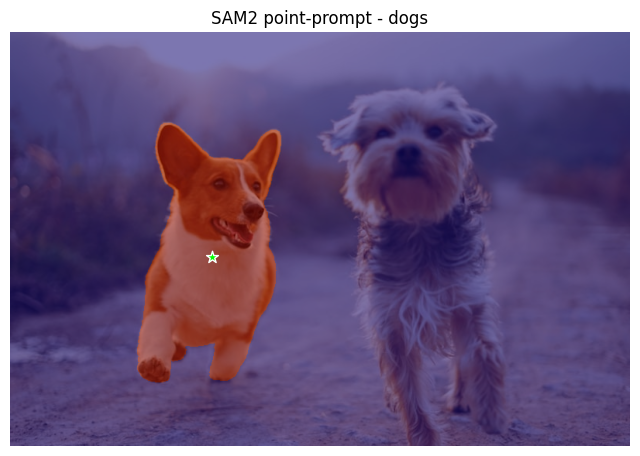

In [ ]:
predictor.set_image(dogs_img)

click_point = np.array([[260, 290]])
click_label = np.array([1])  # 1 = foreground click, 0 = background click

with torch.inference_mode():
    masks, scores, _ = predictor.predict(
        point_coords=click_point, point_labels=click_label, multimask_output=False
    )

predicted_mask = masks[0]
confidence_score = scores[0]
print(f"Confidence: {confidence_score:.3f}")

show_mask_overlay(dogs_img, predicted_mask, click_point, click_label, "SAM2 point-prompt - dogs")

Confidence: 0.928


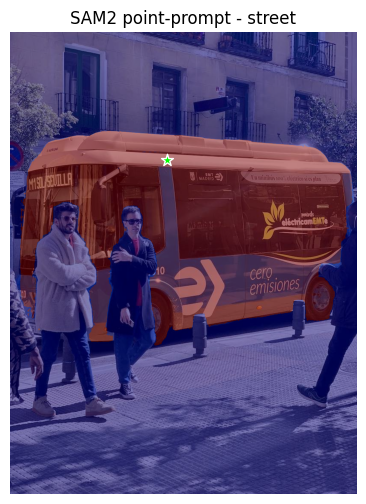

In [ ]:
predictor.set_image(street_img)

click_point = np.array([[367, 298]])
click_label = np.array([1])

with torch.inference_mode():
    masks, scores, _ = predictor.predict(
        point_coords=click_point, point_labels=click_label, multimask_output=False
    )

predicted_mask = masks[0]
confidence_score = scores[0]
print(f"Confidence: {confidence_score:.3f}")

show_mask_overlay(street_img, predicted_mask, click_point, click_label, "SAM2 point-prompt - street")

Best mask index: 1, confidence: 0.958


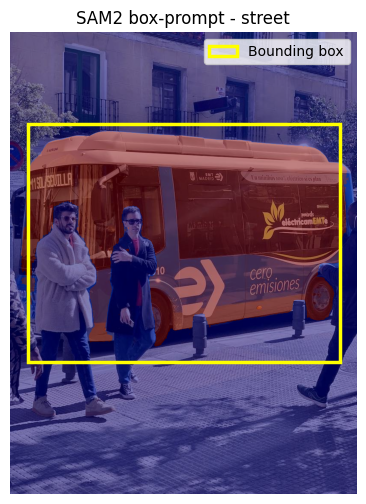

In [ ]:
box_prompt = np.array([42, 214, 772, 771])

predictor.set_image(street_img)

with torch.inference_mode():
    masks, scores, _ = predictor.predict(box=box_prompt, multimask_output=True)


best_idx = int(np.argmax(scores))
predicted_mask = masks[best_idx]
confidence_score = scores[best_idx]
print(f"Best mask index: {best_idx}, confidence: {confidence_score:.3f}")

plt.figure(figsize=(8, 6))
plt.imshow(street_img)
plt.imshow(predicted_mask, alpha=0.5, cmap="jet")


x1, y1, x2, y2 = box_prompt
box_width = x2 - x1
box_height = y2 - y1

rect = patches.Rectangle(
    (x1, y1),
    box_width, box_height,
    linewidth=2.5,
    edgecolor="yellow",
    facecolor="none",
    label="Bounding box",
)
plt.gca().add_patch(rect)
plt.legend()
plt.axis("off")
plt.title("SAM2 box-prompt - street")
plt.show()

Generated 27 masks


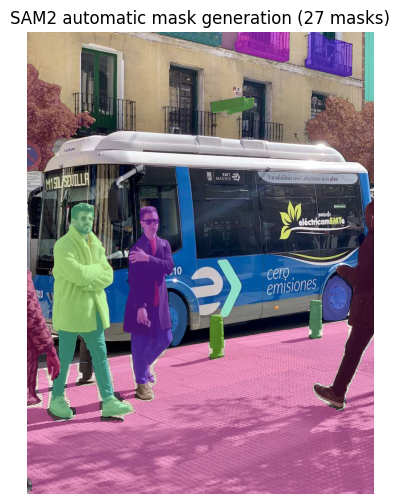

In [ ]:
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

auto_mask_generator = SAM2AutomaticMaskGenerator(sam2_model)

with torch.inference_mode():
    all_masks = auto_mask_generator.generate(street_img)

print(f"Generated {len(all_masks)} masks")

mask_overlay = np.zeros((*street_img.shape[:2], 4))
for item in all_masks:
    binary_mask = item["segmentation"]
    random_color = np.concatenate([np.random.random(3), [0.5]])
    mask_overlay[binary_mask] = random_color

plt.figure(figsize=(8, 6))
plt.imshow(street_img)
plt.imshow(mask_overlay)
plt.axis("off")
plt.title(f"SAM2 automatic mask generation ({len(all_masks)} masks)")
plt.show()

# Streamlit app setup

Cells below install the packages and download the files that `app.py` needs (the SAM2 repo/config, the SAM2 checkpoint weights, and the Streamlit click-coordinates component). Run these once before launching the app.


In [ ]:
# Packages required by app.py:
# - streamlit: the app framework
# - streamlit-image-coordinates: captures the click position on the image
# - sam2 (installed from GitHub): also provides the "configs/sam2.1/sam2.1_hiera_s.yaml"
#   file that build_sam2() needs, bundled inside the package itself
%pip install -q streamlit
%pip install -q streamlit-image-coordinates
%pip install -q "git+https://github.com/facebookresearch/sam2.git"


In [ ]:
import os
import urllib.request

# SAM2 checkpoint weights (same file/URL used inside app.py's load_model()).
# Downloading it here means app.py finds it already on disk and skips its
# own download on first run.
SAM2_CHECKPOINT = "sam2.1_hiera_small.pt"
SAM2_CHECKPOINT_URL = (
    "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt"
)

if not os.path.exists(SAM2_CHECKPOINT):
    print("Downloading SAM2 checkpoint...")
    urllib.request.urlretrieve(SAM2_CHECKPOINT_URL, SAM2_CHECKPOINT)
    print("Done.")
else:
    print("Checkpoint already present, skipping download.")


In [ ]:
# Launch the app (e.g. in Colab, use a tunnel like localtunnel/ngrok to view it,
# since Streamlit's dev server isn't reachable directly from a notebook environment).
!streamlit run app.py --server.port 8501


# Download files to your PC

Run this on Colab to grab the checkpoint that `app.py` needs and save it to
your own machine (via your browser's download prompt). Put the downloaded
file in the same folder as `app.py` on your PC — that way `app.py` finds it
already there and skips its own download on first run.


In [ ]:
import os
import urllib.request

SAM2_CHECKPOINT = "sam2.1_hiera_small.pt"
SAM2_CHECKPOINT_URL = (
    "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt"
)

if not os.path.exists(SAM2_CHECKPOINT):
    print("Downloading SAM2 checkpoint (~180MB) to the Colab VM...")
    urllib.request.urlretrieve(SAM2_CHECKPOINT_URL, SAM2_CHECKPOINT)
    print("Done.")
else:
    print("Checkpoint already present on the Colab VM, skipping download.")

# Trigger a browser download of the checkpoint to your local PC.
# This only works when run inside Google Colab.
try:
    from google.colab import files
    files.download(SAM2_CHECKPOINT)
except ImportError:
    print(
        "Not running in Colab — open the Files panel on the left and "
        f"download '{SAM2_CHECKPOINT}' manually, or copy it from disk directly."
    )


### (Optional) also download app.py itself

Skip this if you already have `app.py` saved locally — it only makes sense
if `app.py` was uploaded into this Colab session and you want a copy on
your PC too.


In [ ]:
import os

try:
    from google.colab import files
    if os.path.exists("app.py"):
        files.download("app.py")
    else:
        print("app.py not found in this Colab session's working directory.")
except ImportError:
    print("Not running in Colab — nothing to do here.")
